<a href="https://colab.research.google.com/github/14marcos1/curso_colab_2026/blob/main/acre_2010_2023_chatgpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gerar código

Atue como um especialista em engenharia de dados de saúde pública e crie um script em Python para o Google Colab para extrair dados do Sistema de Informações sobre Mortalidade (SIM/DATASUS).

Siga RIGOROSAMENTE os parâmetros e as regras de arquitetura fornecidas.

---
PARÂMETROS DA PESQUISA (Ajuste se necessário):
- Estado (UF): [AC]
- Período: [2010 a 2023]
- Grupo 1: "Neoplasias" -> CIDs-10 iniciados com as letras ['C', 'D']
- Grupo 2: "Aparelho Circulatório" -> CIDs-10 iniciados com a letra ['I']
---

REGRAS OBRIGATÓRIAS DE ARQUITETURA DO CÓDIGO (NÃO MUDAR OU OMITIR):

1. INSTALAÇÃO DE DEPENDÊNCIAS DE SISTEMA (LINUX E PYTHON):
   Instale no início do script os pacotes de sistema necessários para converter os arquivos do DATASUS:
   !apt-get update -qq && !apt-get install -y -qq p7zip-full
   !pip install pyreaddbc dbfread pandas -q

2. IMPORTAÇÃO E SINTAXE OBRIGATÓRIA DO DBC2DBF (CRÍTICO):
   - Importe a função usando exatamente: `from pyreaddbc import dbc2dbf`
   - Para converter os arquivos, passe estritamente DUAS strings com os caminhos completos de entrada e saída: `dbc2dbf(caminho_dbc, caminho_dbf)`
   - Nunca use `dbc2dbf.dbc2dbf()` nem métodos sem o parâmetro do arquivo de saída.

3. BAIXAMENTO E CONVERSÃO (NÃO USE PYSUS ONLINE):
   - Baixe os arquivos do FTP oficial: "ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/DO{UF}{ANO}.DBC"
   - Adicione tentativa de download com extensão minúscula (.dbc) caso a maiúscula falhe.
   - Leia o arquivo .dbf convertido com `dbfread.DBF(..., encoding="latin1")`.
   - Remova os arquivos temporários (.dbc e .dbf) do disco a cada loop para não lotar a memória do Colab.

4. TRATAMENTO DA COLUNA E AGRUPAMENTO:
   - Filtre a coluna 'CAUSABAS' utilizando os prefixos de CID fornecidos nos parâmetros.
   - Conte o total de óbitos ano a ano para cada grupo ("Neoplasias" e "Aparelho Circulatório").

5. PADRONIZAÇÃO RÍGIDA DA SAÍDA:
   - O arquivo de saída DEVE ser salvo OBRIGATORIAMENTE no formato: f"mortalidade_{UF.lower()}_consolidado.csv" (Exemplo para o Acre: "mortalidade_ac_consolidado.csv").
   - A planilha DEVE conter exatamente 3 colunas com estes nomes em maiúsculo: ANO, GRUPO, OBITOS.
   - Inclua no final o comando `google.colab.files.download()` para baixar a planilha no computador.
   - Entregue o código completo em um ÚNICO bloco executável.

In [2]:
# ==============================================================================
# SCRIPT DE EXTRAÇÃO - SIM/DATASUS (Sistema de Informações sobre Mortalidade)
# UF: AC | Período: 2010-2023
# Grupos: Neoplasias (C, D) | Aparelho Circulatório (I)
# ==============================================================================

# --- 1. INSTALAÇÃO DE DEPENDÊNCIAS DE SISTEMA E PYTHON ---
!apt-get update -qq
!apt-get install -y -qq p7zip-full
!pip install pyreaddbc dbfread pandas -q

# --- IMPORTS ---
import os
import urllib.request
import pandas as pd
from dbfread import DBF
from pyreaddbc import dbc2dbf

# --- 2. PARÂMETROS DA PESQUISA ---
UF = "AC"
ANO_INICIO = 2010
ANO_FIM = 2023

GRUPOS_CID = {
    "Neoplasias": ["C", "D"],
    "Aparelho Circulatório": ["I"]
}

# Diretório temporário de trabalho
DIR_TEMP = "/content/temp_sim"
os.makedirs(DIR_TEMP, exist_ok=True)

# Lista que vai acumular os resultados consolidados
resultados = []

# --- 3. LOOP DE DOWNLOAD, CONVERSÃO E LEITURA ---
for ano in range(ANO_INICIO, ANO_FIM + 1):
    print(f"\n{'='*60}")
    print(f"Processando ano: {ano}")
    print(f"{'='*60}")

    nome_base = f"DO{UF}{ano}"
    caminho_dbc = os.path.join(DIR_TEMP, f"{nome_base}.dbc")
    caminho_dbf = os.path.join(DIR_TEMP, f"{nome_base}.dbf")

    # URLs de tentativa: maiúscula (.DBC) primeiro, minúscula (.dbc) depois
    url_maiuscula = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome_base}.DBC"
    url_minuscula = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome_base}.dbc"

    download_ok = False
    for url_tentativa in [url_maiuscula, url_minuscula]:
        try:
            print(f"Tentando baixar: {url_tentativa}")
            urllib.request.urlretrieve(url_tentativa, caminho_dbc)
            download_ok = True
            print("Download concluído com sucesso.")
            break
        except Exception as e:
            print(f"Falha no download ({url_tentativa}): {e}")

    if not download_ok:
        print(f"AVISO: Não foi possível baixar dados para o ano {ano}. Pulando...")
        continue

    # --- CONVERSÃO DBC -> DBF ---
    try:
        dbc2dbf(caminho_dbc, caminho_dbf)
        print("Conversão DBC -> DBF concluída.")
    except Exception as e:
        print(f"ERRO na conversão DBC->DBF para o ano {ano}: {e}")
        if os.path.exists(caminho_dbc):
            os.remove(caminho_dbc)
        continue

    # --- LEITURA DO DBF ---
    try:
        tabela = DBF(caminho_dbf, encoding="latin1")
        df_ano = pd.DataFrame(iter(tabela))
        print(f"Registros lidos: {len(df_ano)}")
    except Exception as e:
        print(f"ERRO na leitura do DBF para o ano {ano}: {e}")
        for f in [caminho_dbc, caminho_dbf]:
            if os.path.exists(f):
                os.remove(f)
        continue

    # --- 4. TRATAMENTO DA COLUNA E AGRUPAMENTO ---
    if "CAUSABAS" in df_ano.columns:
        df_ano["CAUSABAS"] = df_ano["CAUSABAS"].astype(str).str.strip().str.upper()

        for nome_grupo, prefixos in GRUPOS_CID.items():
            filtro = df_ano["CAUSABAS"].str.startswith(tuple(prefixos))
            total_obitos = int(filtro.sum())

            resultados.append({
                "ANO": ano,
                "GRUPO": nome_grupo,
                "OBITOS": total_obitos
            })

            print(f"  -> {nome_grupo}: {total_obitos} óbitos")
    else:
        print(f"AVISO: Coluna CAUSABAS não encontrada no ano {ano}.")

    # --- REMOÇÃO DOS ARQUIVOS TEMPORÁRIOS ---
    for f in [caminho_dbc, caminho_dbf]:
        if os.path.exists(f):
            os.remove(f)

    del df_ano

print(f"\n{'='*60}")
print("Processamento de todos os anos concluído.")
print(f"{'='*60}")

# --- 5. CONSOLIDAÇÃO E PADRONIZAÇÃO DA SAÍDA ---
df_final = pd.DataFrame(resultados, columns=["ANO", "GRUPO", "OBITOS"])
df_final = df_final.sort_values(by=["ANO", "GRUPO"]).reset_index(drop=True)

nome_arquivo_saida = f"mortalidade_{UF.lower()}_consolidado.csv"
df_final.to_csv(nome_arquivo_saida, index=False, encoding="utf-8-sig")

print(f"\nArquivo salvo: {nome_arquivo_saida}")
print(df_final.head(20))

# --- DOWNLOAD DO ARQUIVO ---
from google.colab import files
files.download(nome_arquivo_saida)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.3 MB/s eta 0:00:00

Processando ano: 2010
Tentando baixar: ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/DOAC2010.DBC
Download concluído com sucesso.
Conversão DBC -> DBF concluída.
Registros lidos: 3009
  -> Neoplasias: 353 óbitos
  -> Aparelho Circulatório: 606 óbitos

Processando ano: 2011
Tentando baixar: ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/DOAC2011.DBC
Download concluído com sucesso.
Conversão DBC -> DBF concluída.
Registros lidos: 3157
  -> Neoplasias: 399 óbitos
  -> Aparelho Circulatório: 715 óbitos

Processando ano: 2012
Tentando baixar: ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/DOAC2012.DBC
Download concluído com sucesso.
Conversão DBC -> DBF concluída.
Registros lidos: 3293
  -> 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# =============================================================================
# SCRIPT DE VISUALIZAÇÃO DE DADOS - SIM/DATASUS
# Especialista em Visualização de Dados de Saúde Pública
# =============================================================================

# -----------------------------------------------------------------------------
# 1. INSTALAÇÃO E IMPORTAÇÃO DE BIBLIOTECAS
# -----------------------------------------------------------------------------

# Instala bibliotecas necessárias
get_ipython().system('pip install plotly pandas -q')

# Importa as bibliotecas
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import os
import glob
from google.colab import files

# -----------------------------------------------------------------------------
# 2. LEITURA FLEXÍVEL DO ARQUIVO CSV (CRÍTICO - ANTI-FALHA)
# -----------------------------------------------------------------------------

def encontrar_arquivo_csv():
    """
    Busca dinamicamente o arquivo CSV consolidado na pasta atual.
    Retorna o nome do arquivo encontrado ou None se não encontrar.
    """
    print("=" * 80)
    print("BUSCANDO ARQUIVO CSV CONSOLIDADO")
    print("=" * 80)

    # Padrões de busca
    padroes = [
        "*_consolidado.csv",
        "mortalidade_*_consolidado.csv",
        "*_consolidado.CSV",
        "mortalidade_*.csv"
    ]

    arquivos_encontrados = []

    for padrao in padroes:
        arquivos = glob.glob(padrao)
        if arquivos:
            arquivos_encontrados.extend(arquivos)

    # Remove duplicatas mantendo ordem
    arquivos_encontrados = list(dict.fromkeys(arquivos_encontrados))

    if arquivos_encontrados:
        print(f"✅ Arquivo(s) encontrado(s):")
        for i, arquivo in enumerate(arquivos_encontrados, 1):
            print(f"   {i}. {arquivo}")

        # Pega o primeiro arquivo encontrado
        arquivo_escolhido = arquivos_encontrados[0]
        print(f"\n📁 Utilizando arquivo: {arquivo_escolhido}")
        return arquivo_escolhido

    return None

def fazer_upload_arquivo():
    """
    Função para orientar o usuário a fazer upload do arquivo CSV.
    """
    print("\n" + "=" * 80)
    print("⚠️ ARQUIVO CSV NÃO ENCONTRADO")
    print("=" * 80)
    print("\n❌ Nenhum arquivo CSV consolidado foi encontrado na pasta atual.")
    print("\n📌 INSTRUÇÕES:")
    print("   1. Certifique-se de que você já executou a Etapa 1 de extração de dados")
    print("   2. O arquivo gerado na Etapa 1 tem o formato: 'mortalidade_XX_consolidado.csv'")
    print("   3. Faça o upload do arquivo CSV usando o botão de arquivos do Colab")
    print("      ou utilizando o código abaixo:")
    print("\n   ```python")
    print("   from google.colab import files")
    print("   uploaded = files.upload()")
    print("   ```")
    print("\n" + "=" * 80)

    # Tenta fazer upload automaticamente
    resposta = input("\nDeseja fazer upload do arquivo agora? (s/n): ").strip().lower()

    if resposta == 's':
        print("\n📤 Faça o upload do arquivo CSV consolidado...")
        uploaded = files.upload()

        # Verifica se algum arquivo foi enviado
        if uploaded:
            arquivo_upload = list(uploaded.keys())[0]
            print(f"\n✅ Arquivo recebido: {arquivo_upload}")
            return arquivo_upload

    return None

# -----------------------------------------------------------------------------
# 3. FUNÇÃO PARA CARREGAR E TRATAR OS DADOS
# -----------------------------------------------------------------------------

def carregar_dados_csv(arquivo_nome):
    """
    Carrega e trata o arquivo CSV, garantindo que as colunas estejam no formato correto.
    """
    try:
        # Lê o arquivo CSV
        df = pd.read_csv(arquivo_nome, encoding='utf-8-sig')
        print(f"\n✅ Arquivo carregado com sucesso: {arquivo_nome}")
        print(f"   Registros: {len(df)}")
        print(f"   Colunas: {df.columns.tolist()}")

        # Verifica se as colunas esperadas existem
        colunas_esperadas = ['ANO', 'GRUPO', 'OBITOS']
        colunas_atuais = df.columns.tolist()

        # Tenta padronizar nomes de colunas (case insensitive)
        for i, coluna in enumerate(colunas_atuais):
            if coluna.upper() == 'ANO':
                df.rename(columns={coluna: 'ANO'}, inplace=True)
            elif coluna.upper() == 'GRUPO':
                df.rename(columns={coluna: 'GRUPO'}, inplace=True)
            elif coluna.upper() == 'OBITOS':
                df.rename(columns={coluna: 'OBITOS'}, inplace=True)

        # Verifica novamente as colunas
        colunas_faltando = [col for col in colunas_esperadas if col not in df.columns]
        if colunas_faltando:
            print(f"⚠️ Colunas faltando: {colunas_faltando}")
            print(f"   Colunas disponíveis: {df.columns.tolist()}")
            return None

        # Convertendo para tipos numéricos
        print("\n🔧 Tratando dados...")
        df['ANO'] = pd.to_numeric(df['ANO'], errors='coerce')
        df['OBITOS'] = pd.to_numeric(df['OBITOS'], errors='coerce')

        # Remove linhas com valores nulos
        df_limpo = df.dropna(subset=['ANO', 'OBITOS'])
        linhas_removidas = len(df) - len(df_limpo)

        if linhas_removidas > 0:
            print(f"   ⚠️ Removidas {linhas_removidas} linhas com dados inválidos")

        # Ordena os dados
        df_limpo = df_limpo.sort_values(['ANO', 'GRUPO']).reset_index(drop=True)

        # Extrai informações úteis
        anos = sorted(df_limpo['ANO'].unique())
        grupos = sorted(df_limpo['GRUPO'].unique())
        uf_extraido = extrair_uf_do_nome(arquivo_nome)

        print(f"✅ Dados tratados com sucesso:")
        print(f"   Período: {min(anos)} a {max(anos)}")
        print(f"   Grupos: {', '.join(grupos)}")
        print(f"   Total de registros: {len(df_limpo)}")

        return df_limpo, uf_extraido, anos, grupos

    except Exception as e:
        print(f"\n❌ Erro ao ler o arquivo {arquivo_nome}: {e}")
        return None, None, None, None

def extrair_uf_do_nome(arquivo_nome):
    """
    Extrai a UF do nome do arquivo.
    """
    try:
        # Tenta extrair UF do padrão "mortalidade_XX_consolidado.csv"
        partes = arquivo_nome.replace('.csv', '').replace('.CSV', '').split('_')
        for parte in partes:
            if len(parte) == 2 and parte.isalpha():
                return parte.upper()

        # Se não encontrar, tenta outras variações
        import re
        padrao = re.compile(r'[a-zA-Z]{2}(?=_consolidado|\.csv)')
        match = padrao.search(arquivo_nome)
        if match:
            return match.group().upper()

        return "XX"  # UF não identificada
    except:
        return "XX"

# -----------------------------------------------------------------------------
# 4. CRIAÇÃO DO GRÁFICO INTERATIVO
# -----------------------------------------------------------------------------

def criar_grafico_interativo(df, uf, anos, grupos):
    """
    Cria um gráfico de linhas interativo profissional.
    """
    print("\n" + "=" * 80)
    print("GERANDO GRÁFICO INTERATIVO")
    print("=" * 80)

    # Define cores para os grupos
    cores = {
        'Neoplasias': '#E74C3C',  # Vermelho
        'Aparelho Circulatório': '#3498DB'  # Azul
    }

    # Cria o gráfico usando plotly.graph_objects para mais controle
    fig = go.Figure()

    for grupo in grupos:
        dados_grupo = df[df['GRUPO'] == grupo].sort_values('ANO')

        fig.add_trace(go.Scatter(
            x=dados_grupo['ANO'],
            y=dados_grupo['OBITOS'],
            mode='lines+markers',
            name=grupo,
            line=dict(
                width=3,
                color=cores.get(grupo, '#2ECC71')
            ),
            marker=dict(
                size=12,
                symbol='circle',
                color=cores.get(grupo, '#2ECC71'),
                line=dict(
                    color='white',
                    width=2
                )
            ),
            text=dados_grupo['OBITOS'].round(0).astype(int),
            textposition='top center',
            textfont=dict(
                family='Arial',
                size=11,
                color='#2C3E50'
            ),
            hovertemplate='<b>%{x}</b><br>' +
                         'Óbitos: %{y:,.0f}<br>' +
                         'Grupo: %{fullData.name}<br>' +
                         '<extra></extra>'
        ))

    # Título do gráfico
    titulo = f"Evolução dos Óbitos por Grupo de Causas<br>" \
             f"<span style='font-size:16px;font-weight:normal;color:#7F8C8D;'>" \
             f"{uf} - {int(anos[0])} a {int(anos[-1])}</span>"

    # Configura o layout do gráfico
    fig.update_layout(
        title=dict(
            text=titulo,
            x=0.5,
            xanchor='center',
            font=dict(
                family='Arial, sans-serif',
                size=22,
                color='#2C3E50'
            )
        ),
        template='plotly_white',
        hovermode='x unified',
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='center',
            x=0.5,
            font=dict(
                family='Arial',
                size=13,
                color='#2C3E50'
            ),
            bgcolor='rgba(255,255,255,0.9)',
            bordercolor='#BDC3C7',
            borderwidth=1
        ),
        xaxis=dict(
            title=dict(
                text='<b>Ano</b>',
                font=dict(
                    family='Arial',
                    size=16,
                    color='#2C3E50'
                )
            ),
            tickmode='array',
            tickvals=sorted(anos),
            ticktext=[str(int(ano)) for ano in sorted(anos)],
            tickfont=dict(
                family='Arial',
                size=13,
                color='#2C3E50'
            ),
            gridcolor='#ECF0F1',
            gridwidth=0.5,
            showline=True,
            linecolor='#BDC3C7',
            linewidth=1.5,
            mirror=True
        ),
        yaxis=dict(
            title=dict(
                text='<b>Número de Óbitos</b>',
                font=dict(
                    family='Arial',
                    size=16,
                    color='#2C3E50'
                )
            ),
            tickfont=dict(
                family='Arial',
                size=13,
                color='#2C3E50'
            ),
            gridcolor='#ECF0F1',
            gridwidth=0.5,
            showline=True,
            linecolor='#BDC3C7',
            linewidth=1.5,
            mirror=True,
            separatethousands=True
        ),
        plot_bgcolor='#FBFCFC',
        paper_bgcolor='#FBFCFC',
        margin=dict(
            l=80,
            r=40,
            t=100,
            b=80
        ),
        font=dict(
            family='Arial',
            color='#2C3E50'
        )
    )

    # Adiciona anotações para valores máximos e mínimos
    for grupo in grupos:
        dados_grupo = df[df['GRUPO'] == grupo].sort_values('ANO')
        max_valor = dados_grupo['OBITOS'].max()
        max_ano = dados_grupo[dados_grupo['OBITOS'] == max_valor]['ANO'].iloc[0]

        min_valor = dados_grupo['OBITOS'].min()
        min_ano = dados_grupo[dados_grupo['OBITOS'] == min_valor]['ANO'].iloc[0]

        # Adiciona anotação para máximo
        fig.add_annotation(
            x=max_ano,
            y=max_valor,
            text=f"<b>Máximo</b><br>{int(max_valor):,}",
            showarrow=True,
            arrowhead=2,
            arrowsize=1.5,
            arrowwidth=2,
            arrowcolor='#7F8C8D',
            ax=40,
            ay=-40,
            font=dict(
                family='Arial',
                size=10,
                color='#7F8C8D'
            ),
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='#BDC3C7',
            borderwidth=1,
            borderpad=4
        )

    # Adiciona fonte com dados de produção
    fig.add_annotation(
        x=1.0,
        y=-0.15,
        xref='paper',
        yref='paper',
        text="<i>Fonte: SIM/DATASUS, 2026</i>",
        showarrow=False,
        font=dict(
            family='Arial',
            size=10,
            color='#95A5A6'
        ),
        xanchor='right',
        yanchor='top'
    )

    return fig

# -----------------------------------------------------------------------------
# 5. FUNÇÃO PARA SALVAR E BAIXAR O GRÁFICO
# -----------------------------------------------------------------------------

def salvar_e_baixar_grafico(fig, uf):
    """
    Salva o gráfico em HTML e faz o download automático.
    """
    nome_arquivo = f"mortalidade_grafico_interativo_{uf.lower()}.html"

    # Salva o HTML
    fig.write_html(nome_arquivo)
    print(f"\n✅ Gráfico salvo como: {nome_arquivo}")

    # Download automático
    try:
        files.download(nome_arquivo)
        print("✅ Download iniciado automaticamente")
    except Exception as e:
        print(f"⚠️ Erro ao baixar o arquivo: {e}")
        print(f"ℹ️ Você pode baixar manualmente o arquivo: {nome_arquivo}")

    return nome_arquivo

# -----------------------------------------------------------------------------
# 6. FUNÇÃO PRINCIPAL
# -----------------------------------------------------------------------------

def main():
    """
    Função principal que coordena todo o processo de visualização.
    """
    print("\n" + "=" * 80)
    print("VISUALIZAÇÃO DE DADOS DO SIM/DATASUS")
    print("=" * 80)

    # Passo 1: Encontrar o arquivo CSV
    arquivo_nome = encontrar_arquivo_csv()

    if arquivo_nome is None:
        # Passo 2: Fazer upload se necessário
        arquivo_nome = fazer_upload_arquivo()

        if arquivo_nome is None:
            print("\n❌ Não foi possível prosseguir sem um arquivo CSV.")
            return

    # Passo 3: Carregar e tratar os dados
    df, uf, anos, grupos = carregar_dados_csv(arquivo_nome)

    if df is None:
        return

    # Passo 4: Criar o gráfico
    fig = criar_grafico_interativo(df, uf, anos, grupos)

    # Passo 5: Exibir o gráfico
    print("\n" + "=" * 80)
    print("📊 EXIBINDO GRÁFICO INTERATIVO")
    print("=" * 80)
    fig.show()

    # Passo 6: Salvar e fazer download
    salvar_e_baixar_grafico(fig, uf)

    # Passo 7: Resumo final
    print("\n" + "=" * 80)
    print("✅ PROCESSO CONCLUÍDO COM SUCESSO")
    print("=" * 80)
    print(f"\n📊 Resumo dos dados:")
    print(f"   • UF: {uf}")
    print(f"   • Período: {int(anos[0])} a {int(anos[-1])}")
    print(f"   • Grupos analisados: {', '.join(grupos)}")
    print(f"   • Total de registros processados: {len(df)}")
    print(f"\n📁 Arquivos gerados:")
    print(f"   • Gráfico interativo: mortalidade_grafico_interativo_{uf.lower()}.html")
    print(f"\n💡 Dica: O gráfico é interativo - você pode passar o mouse sobre")
    print(f"   as linhas para ver detalhes, zoom e exportar como imagem.")

# -----------------------------------------------------------------------------
# 7. EXECUÇÃO DO SCRIPT
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    main()

print("\n" + "=" * 80)
print("FIM DA EXECUÇÃO")
print("=" * 80)


VISUALIZAÇÃO DE DADOS DO SIM/DATASUS
BUSCANDO ARQUIVO CSV CONSOLIDADO
✅ Arquivo(s) encontrado(s):
   1. mortalidade_ac_consolidado.csv

📁 Utilizando arquivo: mortalidade_ac_consolidado.csv

✅ Arquivo carregado com sucesso: mortalidade_ac_consolidado.csv
   Registros: 28
   Colunas: ['ANO', 'GRUPO', 'OBITOS']

🔧 Tratando dados...
✅ Dados tratados com sucesso:
   Período: 2010 a 2023
   Grupos: Aparelho Circulatório, Neoplasias
   Total de registros: 28

GERANDO GRÁFICO INTERATIVO

📊 EXIBINDO GRÁFICO INTERATIVO



✅ Gráfico salvo como: mortalidade_grafico_interativo_ac.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download iniciado automaticamente

✅ PROCESSO CONCLUÍDO COM SUCESSO

📊 Resumo dos dados:
   • UF: AC
   • Período: 2010 a 2023
   • Grupos analisados: Aparelho Circulatório, Neoplasias
   • Total de registros processados: 28

📁 Arquivos gerados:
   • Gráfico interativo: mortalidade_grafico_interativo_ac.html

💡 Dica: O gráfico é interativo - você pode passar o mouse sobre
   as linhas para ver detalhes, zoom e exportar como imagem.

FIM DA EXECUÇÃO


deepseek



VISUALIZAÇÃO DE DADOS DO SIM/DATASUS - MATPLOTLIB
BUSCANDO ARQUIVO CSV CONSOLIDADO
✅ Arquivo(s) encontrado(s):
   1. mortalidade_ac_consolidado.csv

📁 Utilizando arquivo: mortalidade_ac_consolidado.csv

✅ Arquivo carregado com sucesso: mortalidade_ac_consolidado.csv
   Registros: 28
   Colunas: ['ANO', 'GRUPO', 'OBITOS']

🔧 Tratando dados...
✅ Dados tratados com sucesso:
   Período: 2010 a 2023
   Grupos: Aparelho Circulatório, Neoplasias
   Total de registros: 28

GERANDO GRÁFICO COM MATPLOTLIB (FIGURA E EIXO)

📊 EXIBINDO GRÁFICO


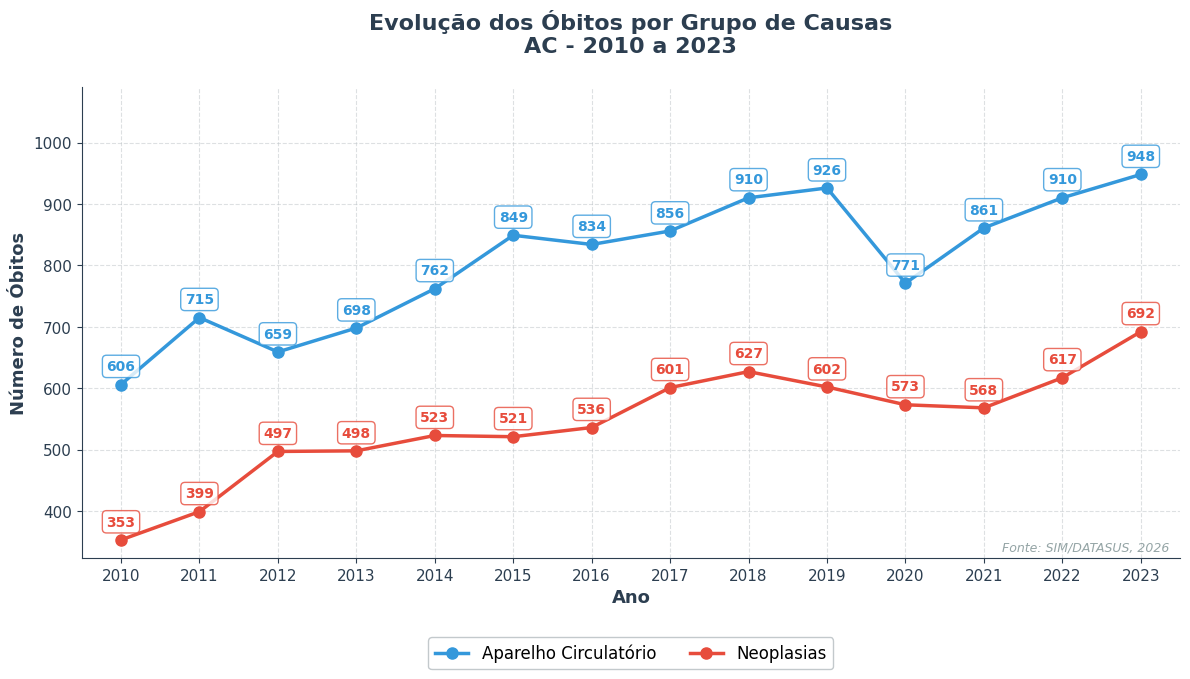


✅ Gráfico salvo como: mortalidade_grafico_matplotlib.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download iniciado automaticamente

✅ PROCESSO CONCLUÍDO COM SUCESSO

📊 Resumo dos dados:
   • Período: 2010 a 2023
   • Grupos analisados: Aparelho Circulatório, Neoplasias
   • Total de registros processados: 28

💡 O gráfico exibe valores exatos sobre cada ponto.
   A legenda foi posicionada abaixo do eixo X para evitar sobreposição.
   O limite do eixo Y foi ampliado para não cortar os valores.

FIM DA EXECUÇÃO


In [4]:
# =============================================================================
# SCRIPT DE VISUALIZAÇÃO DE DADOS - MATPLOTLIB (FIGURA E EIXO)
# Especialista em Visualização de Dados em Saúde Pública
# =============================================================================

# -----------------------------------------------------------------------------
# 1. INSTALAÇÃO E IMPORTAÇÃO DE BIBLIOTECAS
# -----------------------------------------------------------------------------

# Instala bibliotecas necessárias (se necessário)
get_ipython().system('pip install pandas matplotlib -q')

# Importa as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# -----------------------------------------------------------------------------
# 2. LEITURA FLEXÍVEL DO CSV
# -----------------------------------------------------------------------------

def encontrar_arquivo_csv():
    """
    Busca dinamicamente o arquivo CSV consolidado na pasta atual.
    Retorna o nome do arquivo encontrado ou None se não encontrar.
    """
    print("=" * 80)
    print("BUSCANDO ARQUIVO CSV CONSOLIDADO")
    print("=" * 80)

    # Padrões de busca específicos e genéricos
    padroes = [
        "mortalidade_ac_consolidado.csv",
        "mortalidade_acre_consolidado.csv",
        "mortalidade_*_consolidado.csv",
        "*_consolidado.csv"
    ]

    arquivos_encontrados = []

    for padrao in padroes:
        arquivos = glob.glob(padrao)
        if arquivos:
            arquivos_encontrados.extend(arquivos)

    # Remove duplicatas mantendo ordem
    arquivos_encontrados = list(dict.fromkeys(arquivos_encontrados))

    if arquivos_encontrados:
        print(f"✅ Arquivo(s) encontrado(s):")
        for i, arquivo in enumerate(arquivos_encontrados, 1):
            print(f"   {i}. {arquivo}")

        # Pega o primeiro arquivo encontrado
        arquivo_escolhido = arquivos_encontrados[0]
        print(f"\n📁 Utilizando arquivo: {arquivo_escolhido}")
        return arquivo_escolhido

    print("\n❌ Nenhum arquivo CSV consolidado foi encontrado.")
    print("📌 Certifique-se de que o arquivo gerado na Etapa 1 está na pasta atual.")
    return None

def carregar_e_tratar_dados(arquivo_nome):
    """
    Carrega e trata o arquivo CSV, garantindo que as colunas estejam no formato correto.
    """
    try:
        # Lê o arquivo CSV
        df = pd.read_csv(arquivo_nome, encoding='utf-8-sig')
        print(f"\n✅ Arquivo carregado com sucesso: {arquivo_nome}")
        print(f"   Registros: {len(df)}")
        print(f"   Colunas: {df.columns.tolist()}")

        # Verifica se as colunas esperadas existem
        colunas_esperadas = ['ANO', 'GRUPO', 'OBITOS']
        colunas_atuais = df.columns.tolist()

        # Tenta padronizar nomes de colunas (case insensitive)
        for i, coluna in enumerate(colunas_atuais):
            if coluna.upper() == 'ANO':
                df.rename(columns={coluna: 'ANO'}, inplace=True)
            elif coluna.upper() == 'GRUPO':
                df.rename(columns={coluna: 'GRUPO'}, inplace=True)
            elif coluna.upper() == 'OBITOS':
                df.rename(columns={coluna: 'OBITOS'}, inplace=True)

        # Verifica novamente as colunas
        colunas_faltando = [col for col in colunas_esperadas if col not in df.columns]
        if colunas_faltando:
            print(f"⚠️ Colunas faltando: {colunas_faltando}")
            print(f"   Colunas disponíveis: {df.columns.tolist()}")
            return None

        # Convertendo para tipos numéricos
        print("\n🔧 Tratando dados...")
        df['ANO'] = pd.to_numeric(df['ANO'], errors='coerce')
        df['OBITOS'] = pd.to_numeric(df['OBITOS'], errors='coerce')

        # Remove linhas com valores nulos
        df_limpo = df.dropna(subset=['ANO', 'OBITOS'])
        linhas_removidas = len(df) - len(df_limpo)

        if linhas_removidas > 0:
            print(f"   ⚠️ Removidas {linhas_removidas} linhas com dados inválidos")

        # Ordena os dados
        df_limpo = df_limpo.sort_values(['ANO', 'GRUPO']).reset_index(drop=True)

        # Extrai informações úteis
        anos = sorted(df_limpo['ANO'].unique())
        grupos = sorted(df_limpo['GRUPO'].unique())

        print(f"✅ Dados tratados com sucesso:")
        print(f"   Período: {int(min(anos))} a {int(max(anos))}")
        print(f"   Grupos: {', '.join(grupos)}")
        print(f"   Total de registros: {len(df_limpo)}")

        return df_limpo, anos, grupos

    except Exception as e:
        print(f"\n❌ Erro ao ler o arquivo {arquivo_nome}: {e}")
        return None, None, None

# -----------------------------------------------------------------------------
# 3. FUNÇÃO PARA CRIAR O GRÁFICO COM MATPLOTLIB (FIGURA E EIXO)
# -----------------------------------------------------------------------------

def criar_grafico_matplotlib(df, anos, grupos):
    """
    Cria um gráfico de linhas comparativo utilizando Matplotlib com figura e eixo.
    """
    print("\n" + "=" * 80)
    print("GERANDO GRÁFICO COM MATPLOTLIB (FIGURA E EIXO)")
    print("=" * 80)

    # Define as cores conforme parâmetros
    cores = {
        'Aparelho Circulatório': '#3498db',  # Azul
        'Neoplasias': '#e74c3c'              # Vermelho
    }

    # Cria a figura e o eixo explicitamente
    fig, ax = plt.subplots(figsize=(12, 7))

    # Define o título em UMA ÚNICA chamada com quebra de linha
    ax.set_title(
        "Evolução dos Óbitos por Grupo de Causas\nAC - 2010 a 2023",
        fontsize=16,
        fontweight='bold',
        pad=25,
        color='#2C3E50'
    )

    # Cria o gráfico para cada grupo
    for grupo in grupos:
        dados_grupo = df[df['GRUPO'] == grupo].sort_values('ANO')

        # Plota a linha
        ax.plot(
            dados_grupo['ANO'],
            dados_grupo['OBITOS'],
            marker='o',
            linewidth=2.5,
            markersize=8,
            color=cores.get(grupo, '#2ECC71'),
            label=grupo,
            linestyle='-'
        )

        # Adiciona anotações com os valores ACIMA de cada ponto
        for _, row in dados_grupo.iterrows():
            ax.annotate(
                f'{int(row["OBITOS"])}',
                xy=(row['ANO'], row['OBITOS']),
                xytext=(0, 8),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
                color=cores.get(grupo, '#2ECC71'),
                bbox=dict(
                    boxstyle='round,pad=0.3',
                    facecolor='white',
                    edgecolor=cores.get(grupo, '#2ECC71'),
                    alpha=0.8
                )
            )

    # Configuração dos eixos
    ax.set_xlabel(
        'Ano',
        fontsize=13,
        fontweight='bold',
        color='#2C3E50'
    )

    ax.set_ylabel(
        'Número de Óbitos',
        fontsize=13,
        fontweight='bold',
        color='#2C3E50'
    )

    # Força o eixo X a exibir todos os anos como números inteiros
    anos_inteiros = sorted([int(ano) for ano in anos])
    ax.set_xticks(anos_inteiros)
    ax.set_xlim(min(anos_inteiros) - 0.5, max(anos_inteiros) + 0.5)

    # Amplia o limite superior do eixo Y para evitar que números sejam cortados
    max_obitos = df['OBITOS'].max()
    ax.set_ylim(top=max_obitos * 1.15)

    # Ativa a grade de fundo
    ax.grid(True, linestyle='--', alpha=0.5, color='#BDC3C7')

    # Adiciona a legenda com posicionamento seguro ABAIXO do eixo X
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=2,
        fontsize=12,
        frameon=True,
        edgecolor='#BDC3C7',
        facecolor='white',
        framealpha=0.9
    )

    # Configuração adicional dos eixos
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#2C3E50')
    ax.spines['bottom'].set_color('#2C3E50')
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#2C3E50')

    # Adiciona fonte de dados
    ax.text(
        0.99, 0.01,
        'Fonte: SIM/DATASUS, 2026',
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        color='#95A5A6',
        style='italic'
    )

    # Aplica tight_layout para ajustar automaticamente os elementos
    plt.tight_layout()

    return fig, ax

# -----------------------------------------------------------------------------
# 4. FUNÇÃO PRINCIPAL
# -----------------------------------------------------------------------------

def main():
    """
    Função principal que coordena todo o processo de visualização.
    """
    print("\n" + "=" * 80)
    print("VISUALIZAÇÃO DE DADOS DO SIM/DATASUS - MATPLOTLIB")
    print("=" * 80)

    # Passo 1: Encontrar o arquivo CSV
    arquivo_nome = encontrar_arquivo_csv()

    if arquivo_nome is None:
        print("\n❌ Não foi possível prosseguir sem um arquivo CSV.")
        print("📌 Execute a Etapa 1 de extração de dados primeiro.")
        return

    # Passo 2: Carregar e tratar os dados
    df, anos, grupos = carregar_e_tratar_dados(arquivo_nome)

    if df is None:
        print("\n❌ Não foi possível carregar os dados corretamente.")
        return

    # Passo 3: Criar o gráfico
    fig, ax = criar_grafico_matplotlib(df, anos, grupos)

    # Passo 4: Exibir o gráfico
    print("\n" + "=" * 80)
    print("📊 EXIBINDO GRÁFICO")
    print("=" * 80)
    plt.show()

    # Passo 5: Salvar o gráfico (opcional)
    try:
        nome_arquivo = "mortalidade_grafico_matplotlib.png"
        fig.savefig(nome_arquivo, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"\n✅ Gráfico salvo como: {nome_arquivo}")

        # Tenta fazer download no Colab
        try:
            from google.colab import files
            files.download(nome_arquivo)
            print("✅ Download iniciado automaticamente")
        except ImportError:
            pass
    except Exception as e:
        print(f"⚠️ Não foi possível salvar o gráfico: {e}")

    # Resumo final
    print("\n" + "=" * 80)
    print("✅ PROCESSO CONCLUÍDO COM SUCESSO")
    print("=" * 80)
    print(f"\n📊 Resumo dos dados:")
    print(f"   • Período: {int(min(anos))} a {int(max(anos))}")
    print(f"   • Grupos analisados: {', '.join(grupos)}")
    print(f"   • Total de registros processados: {len(df)}")
    print(f"\n💡 O gráfico exibe valores exatos sobre cada ponto.")
    print(f"   A legenda foi posicionada abaixo do eixo X para evitar sobreposição.")
    print(f"   O limite do eixo Y foi ampliado para não cortar os valores.")

# -----------------------------------------------------------------------------
# 5. EXECUÇÃO DO SCRIPT
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    main()

print("\n" + "=" * 80)
print("FIM DA EXECUÇÃO")
print("=" * 80)

ChatGPT

Arquivo encontrado: mortalidade_ac_consolidado.csv


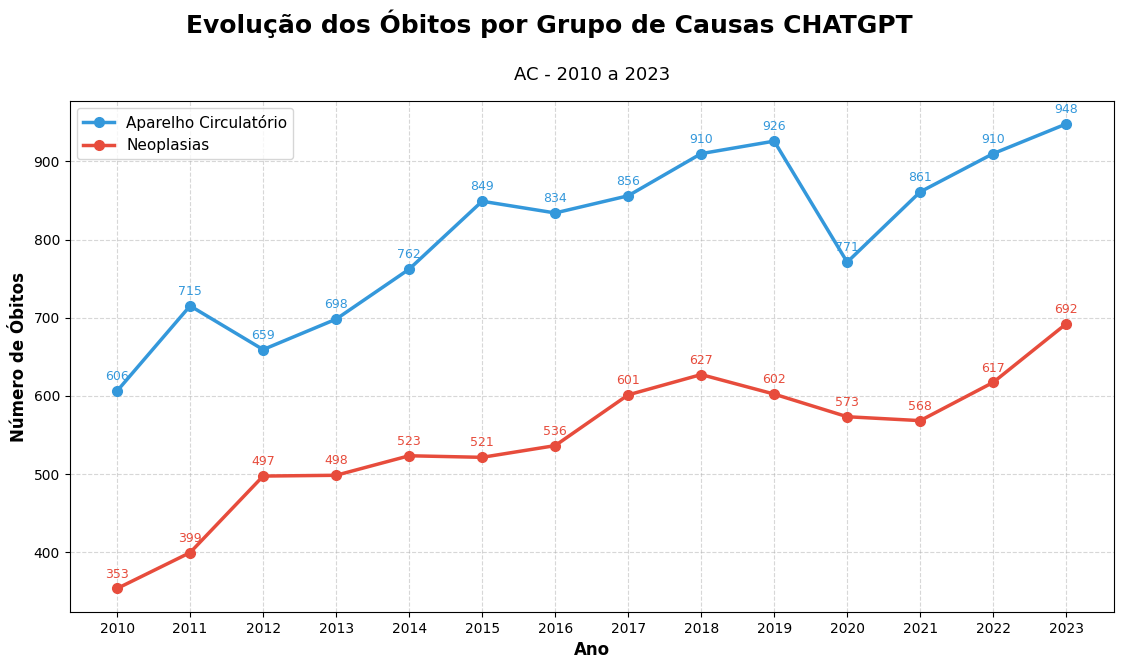

In [5]:
# ============================================================
# GRÁFICO DE MORTALIDADE - SIM / DATASUS
# MATPLOTLIB - GOOGLE COLAB
# ============================================================

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOCALIZAÇÃO FLEXÍVEL DO CSV
# ============================================================

arquivos_preferenciais = [
    "mortalidade_ac_consolidado.csv",
    "mortalidade_acre_consolidado.csv"
]

arquivo_csv = None

# Primeiro procura pelos nomes preferenciais
for arquivo in arquivos_preferenciais:
    if os.path.exists(arquivo):
        arquivo_csv = arquivo
        break

# Se não encontrar, procura qualquer arquivo terminado em
# "_consolidado.csv"
if arquivo_csv is None:
    candidatos = sorted(glob.glob("*_consolidado.csv"))

    if candidatos:
        arquivo_csv = candidatos[0]

# Mensagem de segurança
if arquivo_csv is None:
    raise FileNotFoundError(
        "Nenhum arquivo CSV consolidado foi encontrado.\n"
        "Faça o upload do arquivo 'mortalidade_ac_consolidado.csv' "
        "para o Google Colab e execute novamente esta célula."
    )

print(f"Arquivo encontrado: {arquivo_csv}")


# ============================================================
# 2. LEITURA DO CSV
# ============================================================

df = pd.read_csv(arquivo_csv)


# ============================================================
# 3. VALIDAÇÃO E PADRONIZAÇÃO DOS DADOS
# ============================================================

colunas_obrigatorias = ["ANO", "GRUPO", "OBITOS"]

for coluna in colunas_obrigatorias:
    if coluna not in df.columns:
        raise ValueError(
            f"A coluna '{coluna}' não foi encontrada no arquivo."
        )

# Padronizar textos
df["GRUPO"] = df["GRUPO"].astype(str).str.strip()

# Converter ANO e OBITOS para valores numéricos
df["ANO"] = pd.to_numeric(df["ANO"], errors="coerce")
df["OBITOS"] = pd.to_numeric(df["OBITOS"], errors="coerce")

# Remover registros inválidos
df = df.dropna(
    subset=["ANO", "GRUPO", "OBITOS"]
).copy()

# Garantir anos e óbitos inteiros
df["ANO"] = df["ANO"].astype(int)
df["OBITOS"] = df["OBITOS"].astype(int)

# Ordenar os dados
df = df.sort_values(["ANO", "GRUPO"])


# ============================================================
# 4. SEPARAÇÃO DOS GRUPOS
# ============================================================

circulatorio = (
    df[df["GRUPO"] == "Aparelho Circulatório"]
    .sort_values("ANO")
)

neoplasias = (
    df[df["GRUPO"] == "Neoplasias"]
    .sort_values("ANO")
)

# Checagem de segurança
if circulatorio.empty:
    raise ValueError(
        "Não foram encontrados dados para "
        "'Aparelho Circulatório'."
    )

if neoplasias.empty:
    raise ValueError(
        "Não foram encontrados dados para 'Neoplasias'."
    )


# ============================================================
# 5. CONFIGURAÇÃO DA FIGURA
# ============================================================

plt.figure(figsize=(12, 7))


# ============================================================
# 6. PLOTAGEM - APARELHO CIRCULATÓRIO
# ============================================================

plt.plot(
    circulatorio["ANO"],
    circulatorio["OBITOS"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#3498db",
    label="Aparelho Circulatório"
)


# ============================================================
# 7. PLOTAGEM - NEOPLASIAS
# ============================================================

plt.plot(
    neoplasias["ANO"],
    neoplasias["OBITOS"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#e74c3c",
    label="Neoplasias"
)


# ============================================================
# 8. VALORES SOBRE OS PONTOS - CIRCULATÓRIO
# ============================================================

for ano, obitos in zip(
    circulatorio["ANO"],
    circulatorio["OBITOS"]
):
    plt.annotate(
        f"{obitos}",
        xy=(ano, obitos),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="#3498db"
    )


# ============================================================
# 9. VALORES SOBRE OS PONTOS - NEOPLASIAS
# ============================================================

for ano, obitos in zip(
    neoplasias["ANO"],
    neoplasias["OBITOS"]
):
    plt.annotate(
        f"{obitos}",
        xy=(ano, obitos),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="#e74c3c"
    )


# ============================================================
# 10. TÍTULO E SUBTÍTULO
# ============================================================

plt.suptitle(
    "Evolução dos Óbitos por Grupo de Causas CHATGPT",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

plt.title(
    "AC - 2010 a 2023",
    fontsize=13,
    pad=15
)


# ============================================================
# 11. EIXOS
# ============================================================

plt.xlabel(
    "Ano",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Número de Óbitos",
    fontsize=12,
    fontweight="bold"
)

# Todos os anos como números inteiros
plt.xticks(
    sorted(df["ANO"].unique())
)


# ============================================================
# 12. GRADE
# ============================================================

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)


# ============================================================
# 13. LEGENDA
# ============================================================

plt.legend(
    loc="upper left",
    frameon=True,
    fontsize=11
)


# ============================================================
# 14. AJUSTE DAS MARGENS
# ============================================================

plt.subplots_adjust(
    top=0.85,
    bottom=0.12,
    left=0.10,
    right=0.97
)


# ============================================================
# 15. EXIBIÇÃO FINAL
# ============================================================

plt.show()